
--- Métricas de Avaliação dos Clusters ---
Silhouette Score (Coesão/Separação global): 0.9339
Calinski-Harabasz Score (Separação x Coesão): 5079.99
Davies-Bouldin Score: 0.9919


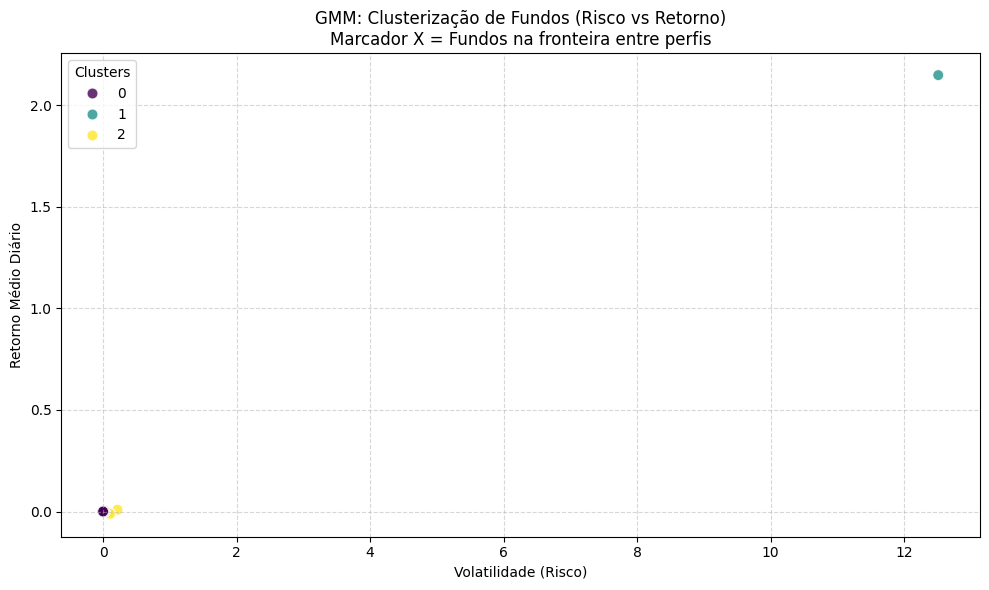

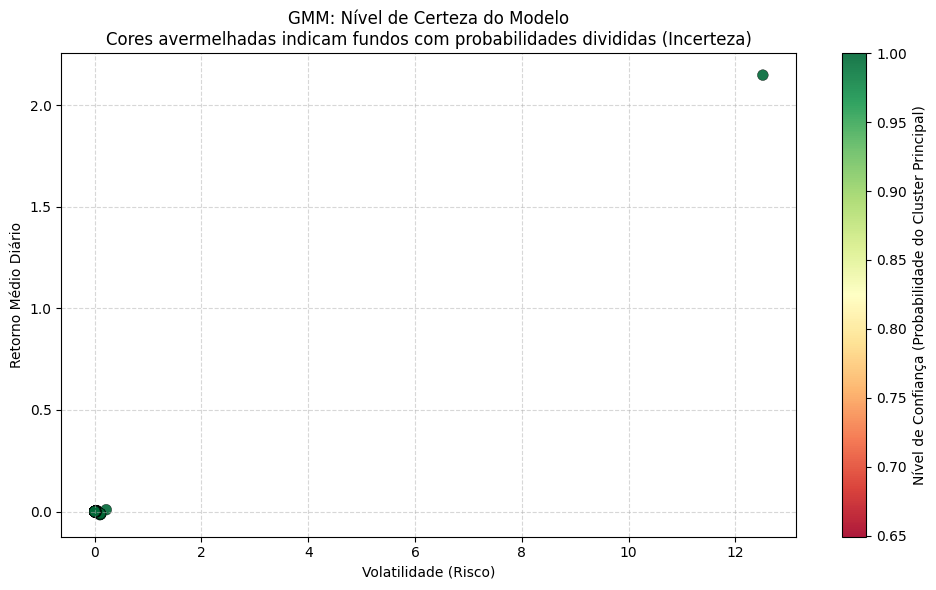


--- Exemplo de Fundos na Fronteira (Soft Clustering) ---
O modelo separou os fundos com alta confiança. Nenhum fundo de transição detectado.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


df = pd.read_csv('matriz_risco_fundos.csv')


colunas_features = ['DIAS_OPERADOS', 'RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']
X = df[colunas_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_componentes = 3
gmm = GaussianMixture(n_components=n_componentes, covariance_type='full', random_state=42)

df['Cluster_GMM'] = gmm.fit_predict(X_scaled)

probabilidades = gmm.predict_proba(X_scaled)

for i in range(n_componentes):
    df[f'Probabilidade_Cluster_{i}'] = probabilidades[:, i]


df['Confianca'] = np.max(probabilidades, axis=1)
df['Fronteira'] = df['Confianca'] < 0.60

sil_score = silhouette_score(X_scaled, df['Cluster_GMM'])
ch_score = calinski_harabasz_score(X_scaled, df['Cluster_GMM'])
db_score = davies_bouldin_score(X_scaled, df['Cluster_GMM'])

print("\n--- Métricas de Avaliação dos Clusters ---")
print(f"Silhouette Score (Coesão/Separação global): {sil_score:.4f}")
print(f"Calinski-Harabasz Score (Separação x Coesão): {ch_score:.2f}")
print(f"Davies-Bouldin Score: {db_score:.4f}")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df[~df['Fronteira']], 
    x='VOLATILIDADE_RISCO', 
    y='RETORNO_MEDIO_DIARIO', 
    hue='Cluster_GMM', 
    palette='viridis', 
    alpha=0.8,
    s=60
)

sns.scatterplot(
    data=df[df['Fronteira']], 
    x='VOLATILIDADE_RISCO', 
    y='RETORNO_MEDIO_DIARIO', 
    color='red', 
    marker='X', 
    s=100, 
    label='Fundos de Transição (Incerteza)'
)

plt.title('GMM: Clusterização de Fundos (Risco vs Retorno)\nMarcador X = Fundos na fronteira entre perfis')
plt.xlabel('Volatilidade (Risco)')
plt.ylabel('Retorno Médio Diário')
plt.legend(title='Clusters')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['VOLATILIDADE_RISCO'], 
    df['RETORNO_MEDIO_DIARIO'], 
    c=df['Confianca'], 
    cmap='RdYlGn', # Vermelho = Baixa confiança, Verde = Alta confiança
    alpha=0.9,
    s=60,
    edgecolors='k',
    linewidth=0.3
)

cbar = plt.colorbar(scatter)
cbar.set_label('Nível de Confiança (Probabilidade do Cluster Principal)')

plt.title('GMM: Nível de Certeza do Modelo\nCores avermelhadas indicam fundos com probabilidades divididas (Incerteza)')
plt.xlabel('Volatilidade (Risco)')
plt.ylabel('Retorno Médio Diário')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n--- Exemplo de Fundos na Fronteira (Soft Clustering) ---")
fronteira_df = df[df['Fronteira']].head(5)
if not fronteira_df.empty:
    colunas_print = ['CNPJ_FUNDO', 'Cluster_GMM', 'Probabilidade_Cluster_0', 'Probabilidade_Cluster_1', 'Probabilidade_Cluster_2']
    print(fronteira_df[colunas_print])
else:
    print("O modelo separou os fundos com alta confiança. Nenhum fundo de transição detectado.")